# FAPE, SBA Agricultural Loans Stage 2: ThresholdOptimizer
## Agricultural/Financial Domain, Business Type Fairness Intervention

**Dataset:** SBA 7(a) Agricultural Loans FY1991-2024, 15,811 records (excl. Unknown businesstype)  
**Sensitive:** businesstype (0=Corporation, 1=Individual, 2=Partnership)  
**Target:** loan default (binary), 5.2% default rate (severe imbalance)  

**Key findings:**
- Baseline DP gap minimal (0.005-0.009), smallest in FAPE across all domains
- ThresholdOptimizer worsens fairness, negative improvement across all models
- GB DIR 0.653→1.095, overcorrects past parity after DP constraint
- Cross-domain finding: agricultural lending near-fair on business type proxy
- No direct race/gender, ECOA proxy-based audit; USDA NASS race data in EDA
- LSMS Nigeria considered and excluded, outside US regulatory scope
- ThresholdOptimizer non-deterministic in fairlearn 0.13.0, results vary slightly between runs

In [1]:
import sys, os, warnings, logging
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore'); logging.disable(logging.CRITICAL)
import numpy as np
from IPython.display import Image
from stage2_agricultural_threshold import run_stage2
print('Imports complete')

Imports complete


In [2]:
import os
os.chdir('..')  # move to repo root so data paths resolve
baseline, dp_results, eo_results, btype_test = run_stage2()
os.chdir('notebooks')
print('Stage 2 complete')

FAPE Phase 4, Agricultural Stage 2: ThresholdOptimizer
Loading SBA 7(a) agricultural loans FY1991-2024...


  FY1991-1999: 337,033 total | 4,445 agricultural NAICS-11


  FY2000-2009: 690,333 total | 4,931 agricultural NAICS-11


  FY2010-2019: 545,751 total | 8,632 agricultural NAICS-11


  FY2020-Present: 373,981 total | 3,918 agricultural NAICS-11
  Combined agricultural records: 21,926
  After binary outcome filter: 15,845

  Loan status distribution:
    Paid In Full: 15,015
    Charged Off:  830

  Top agricultural NAICS categories:
naicsdescription
Broilers and Other Meat Type Chicken Production     6335
Logging                                             1756
Support Activities for Animal Production            1097
Chicken Egg Production                               946
Broilers and Other Meat Type Chicken Production      853

   sba_agricultural: 15,845 records | 8 features | default rate: 0.052

  n=15,811 | default_rate=5.2% | severe imbalance
  Primary sensitive: businesstype (0=Corp 1=Individual 2=Partnership)
  Note: No direct race/gender, ECOA proxy-based audit
  Note: ThresholdOptimizer non-deterministic in fairlearn 0.13.0

--- Baseline Results (Stage 1 reference) ---
  LogisticRegression        AUC=0.727 DP_diff=0.005 EO_diff=0.005


...

Loading SBA 7(a) agricultural loans FY1991-2024...


  FY1991-1999: 337,033 total | 4,445 agricultural NAICS-11


  FY2000-2009: 690,333 total | 4,931 agricultural NAICS-11


  FY2010-2019: 545,751 total | 8,632 agricultural NAICS-11


  FY2020-Present: 373,981 total | 3,918 agricultural NAICS-11
  Combined agricultural records: 21,926
  After binary outcome filter: 15,845

  Loan status distribution:
    Paid In Full: 15,015
    Charged Off:  830

  Top agricultural NAICS categories:
naicsdescription
Broilers and Other Meat Type Chicken Production     6335
Logging                                             1756
Support Activities for Animal Production            1097
Chicken Egg Production                               946
Broilers and Other Meat Type Chicken Production      853

   sba_agricultural: 15,845 records | 8 features | default rate: 0.052
  Fig 8 saved -- agricultural_state_prediction_rates.png
  States analyzed: 40 | max-min gap: 0.160

--- Agricultural Stage 2 complete ---
  7 figures saved to figures/stage2/
  Business type fairness intervention applied, ECOA proxy-based audit
Stage 2 complete


## 1. Accuracy-Fairness Tradeoff

Baseline DP gap already minimal. DP constraint worsens both accuracy and fairness, no beneficial tradeoff.

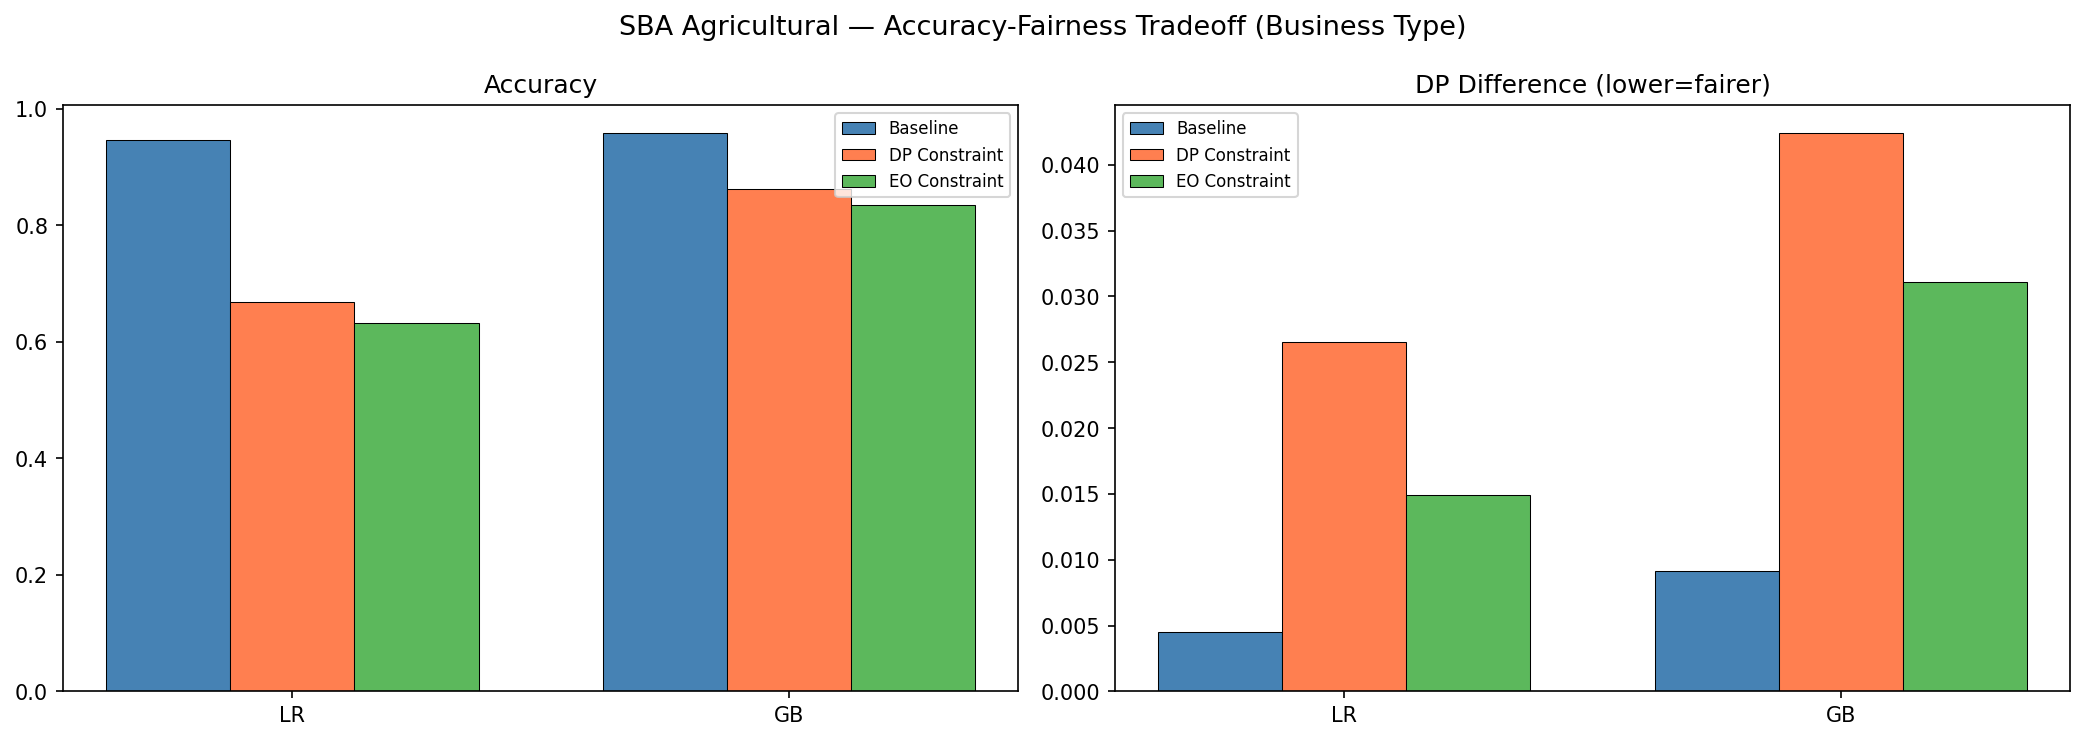

In [3]:
Image('../figures/stage2/agricultural_accuracy_fairness_tradeoff.png')

## 2. Fairness Improvement, Business Type

Negative improvement across all models, ThresholdOptimizer actively worsens fairness when baseline gap is near-zero.

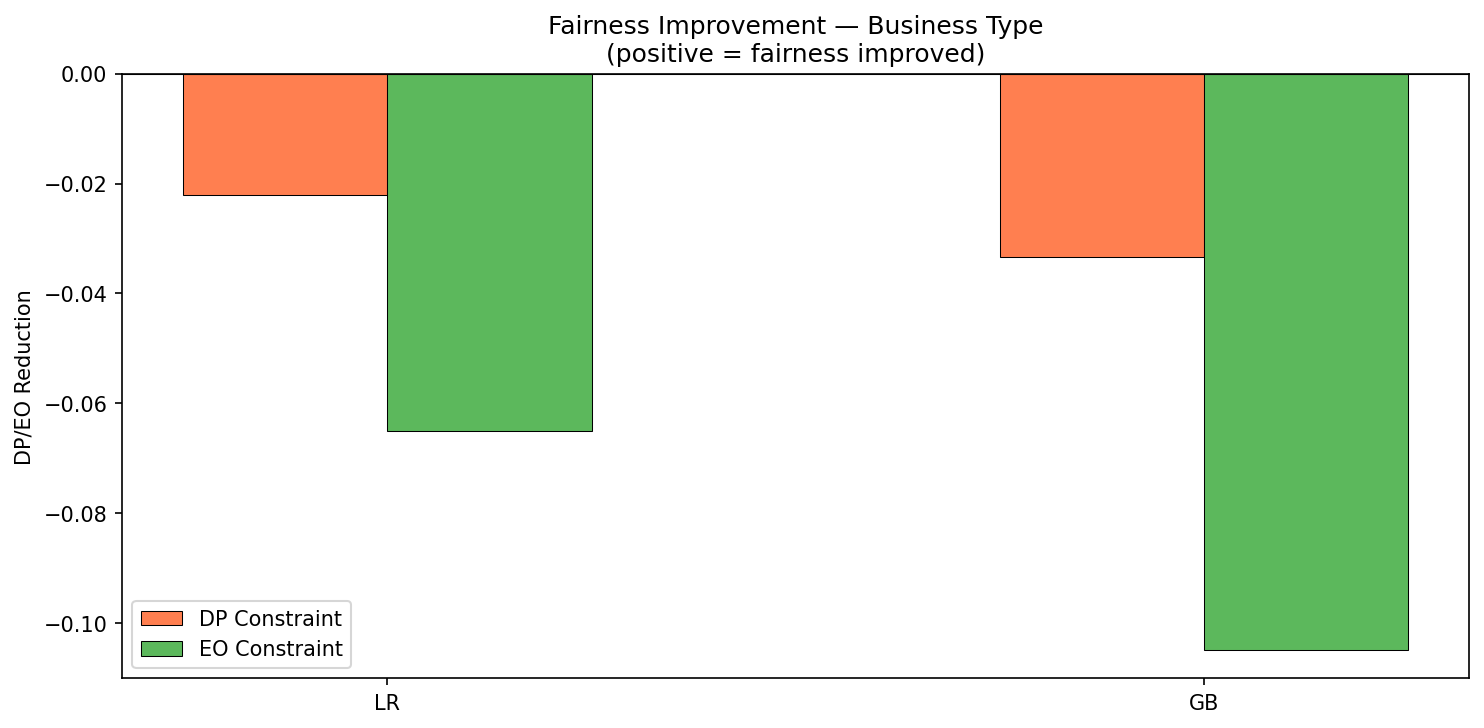

In [4]:
Image('../figures/stage2/agricultural_fairness_improvement.png')

## 3. Cost-Gain Scatter

All points in negative gain quadrant, accuracy cost with no fairness benefit.

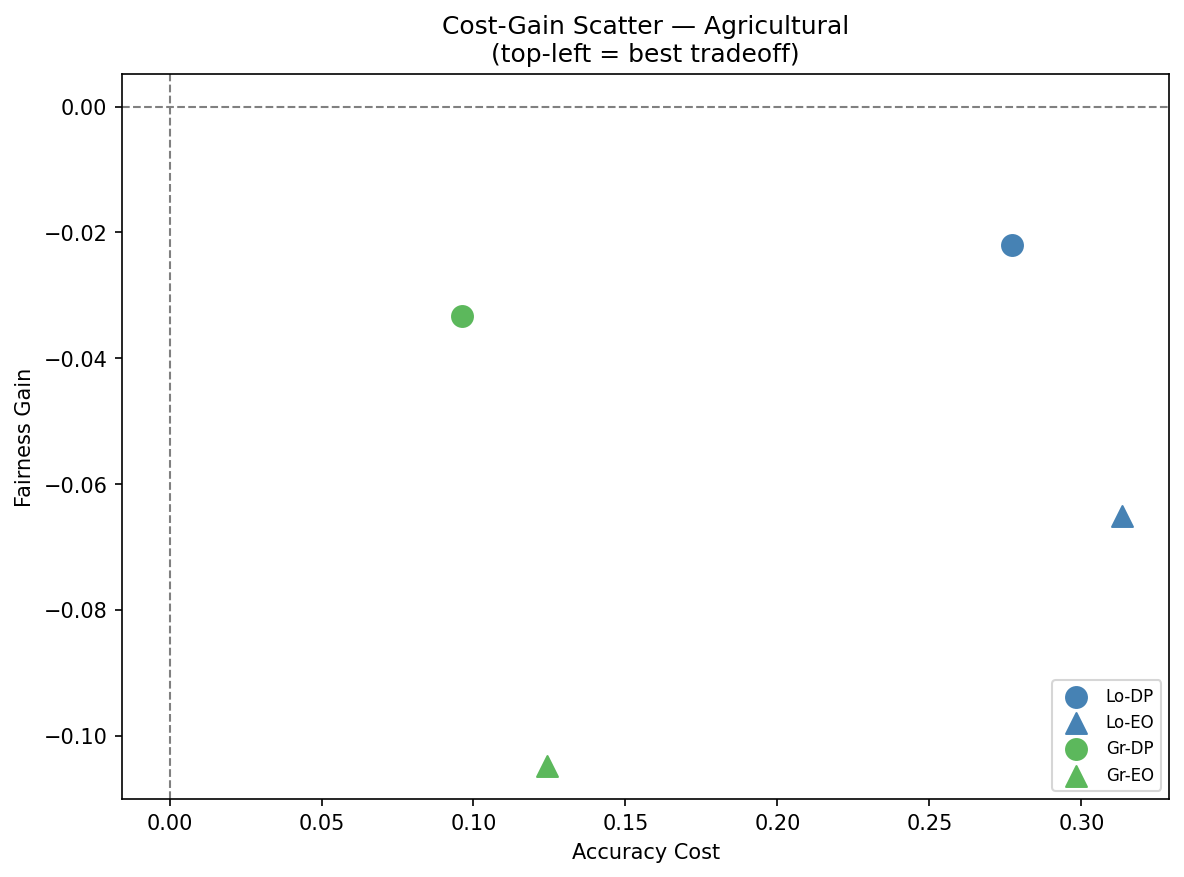

In [5]:
Image('../figures/stage2/agricultural_cost_gain_scatter.png')

## 4. Business Type Prediction Rates

Baseline rates near-equal across Corporation/Individual/Partnership. DP constraint raises all rates uniformly, no selective correction.

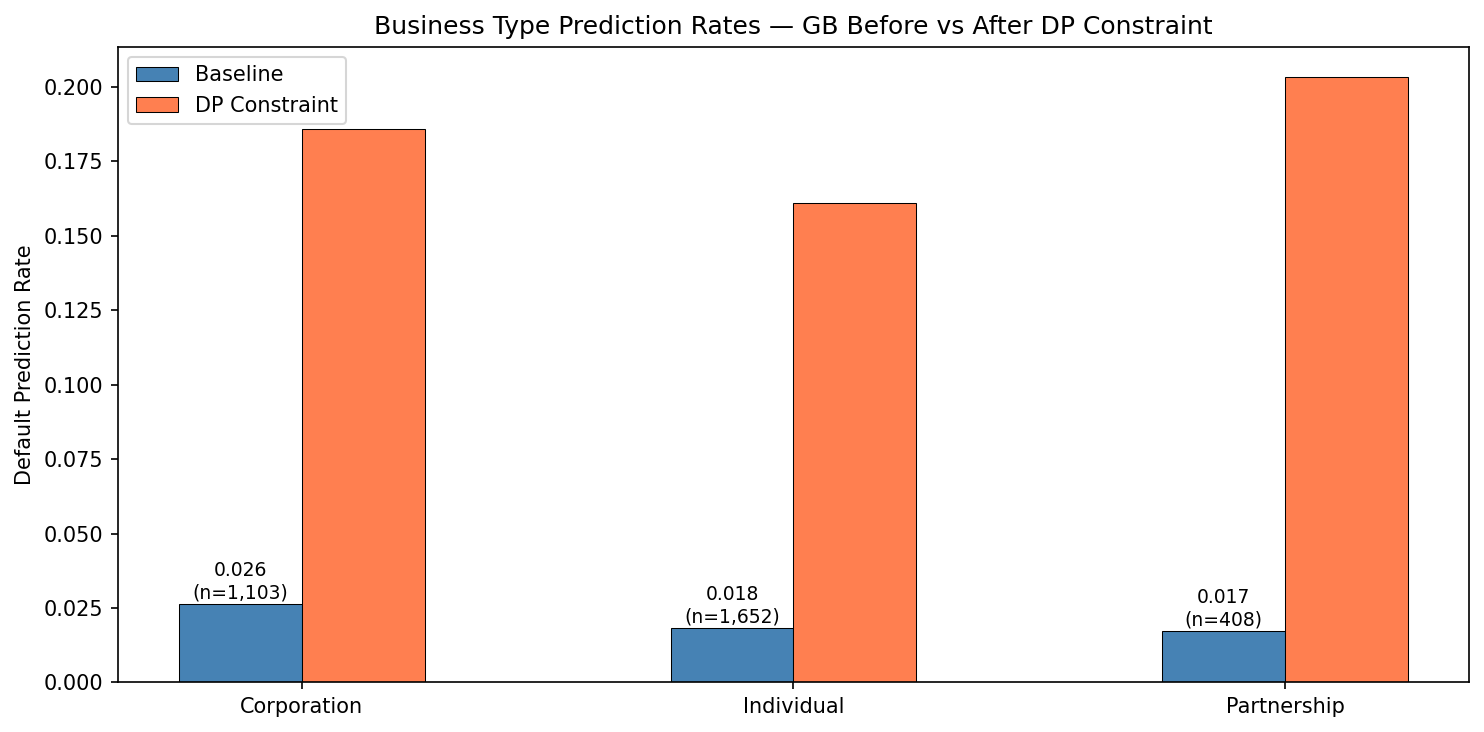

In [6]:
Image('../figures/stage2/agricultural_btype_prediction_rates.png')

## 5. DIR, Partnership vs Corporation

GB baseline DIR=0.653, below EEOC 0.8. After DP constraint DIR=1.095, overcorrects past parity. LR DIR=0.000 baseline (zero Partnership predictions).

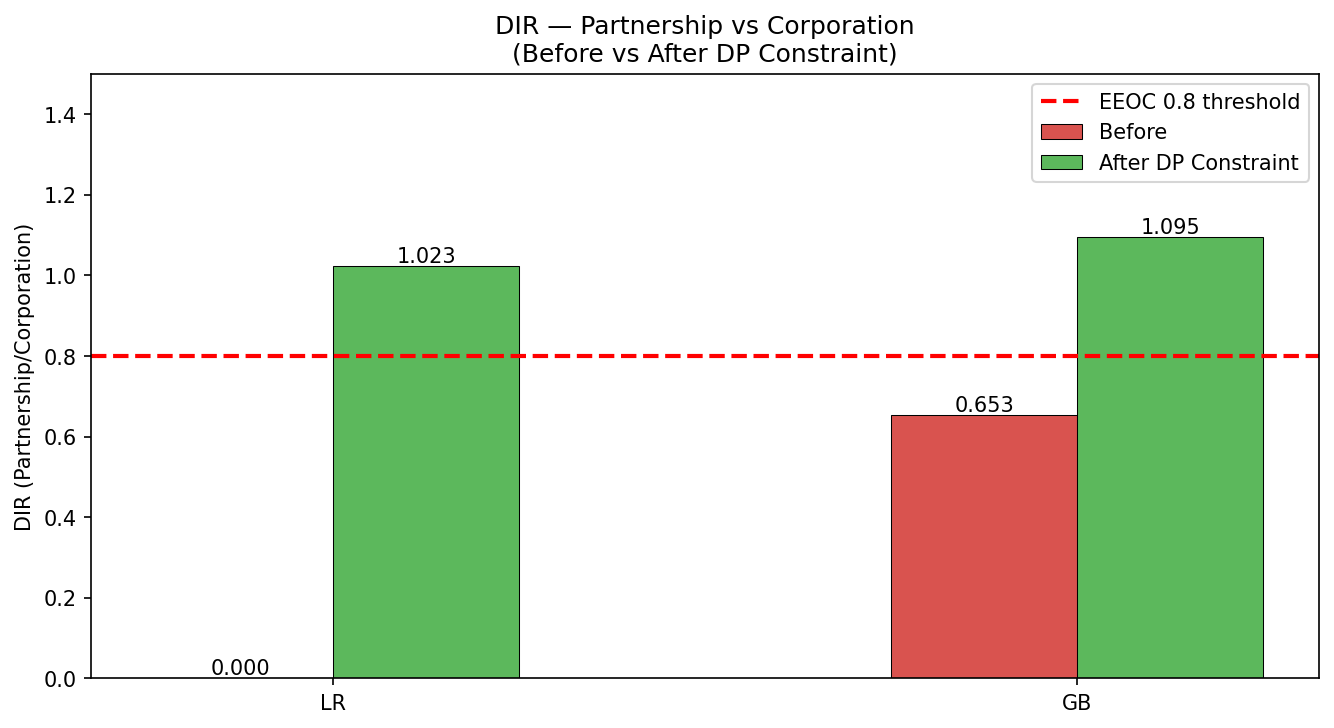

In [7]:
Image('../figures/stage2/agricultural_dir_before_after.png')

## 6. F1 Comparison

F1 affected by 5.2% default rate. AUC is primary metric. GB AUC=0.938, highest baseline AUC in FAPE.

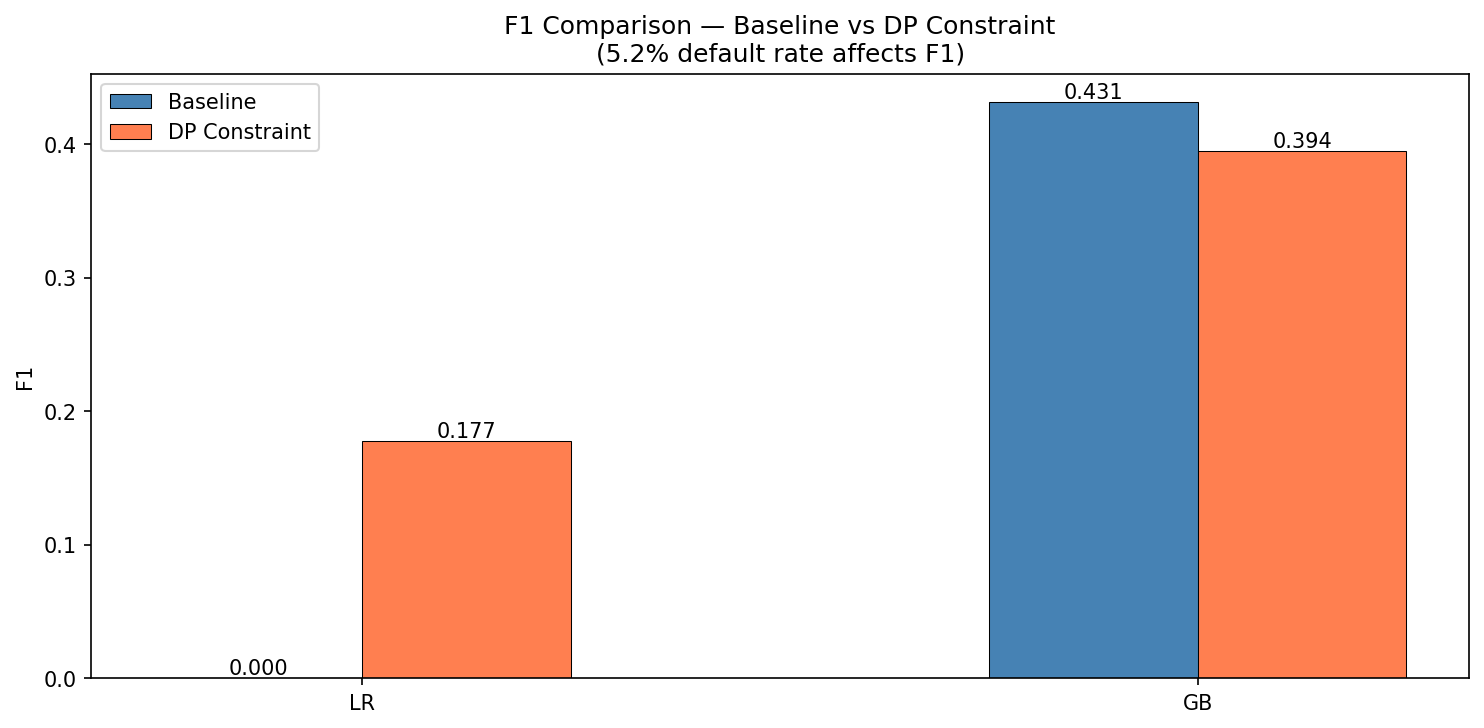

In [8]:
Image('../figures/stage2/agricultural_f1_comparison.png')

## 7. FPR/FNR by Business Type

FPR/FNR near-equal across business types in baseline, confirms near-fair baseline. DP constraint equalizes prediction rates but increases error rates.

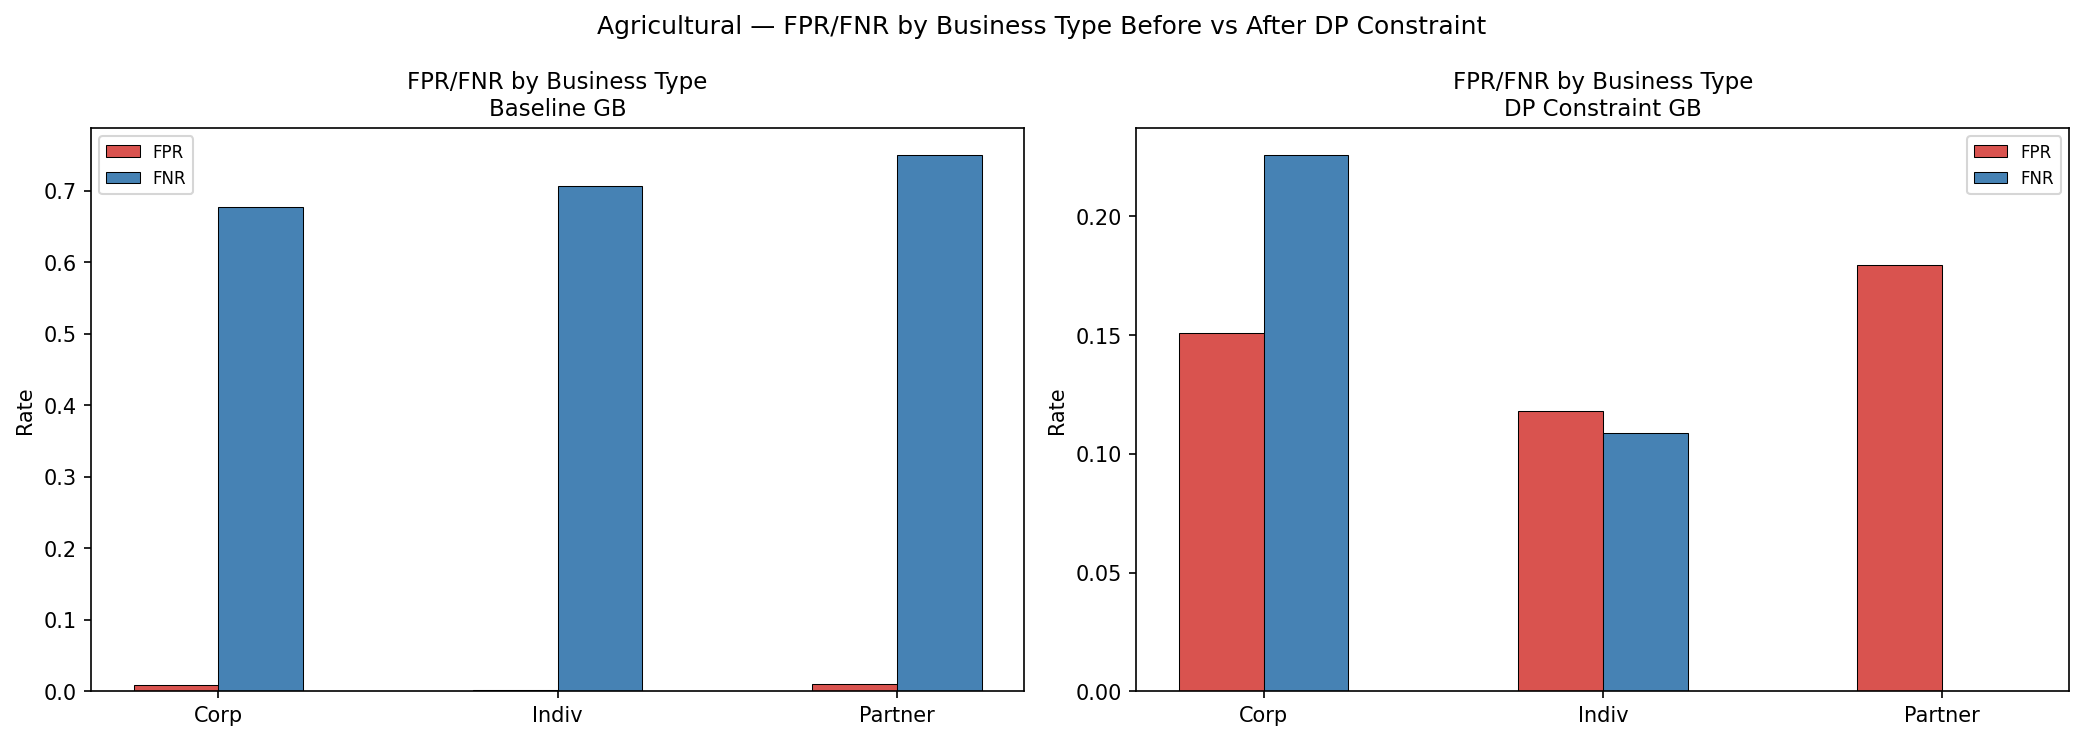

In [9]:
Image('../figures/stage2/agricultural_fpr_fnr_by_btype.png')

## 8. Geographic State Default Prediction Rates

40 states with n≥20. Max-min gap = 0.160, meaningful geographic disparity despite near-fair business type baseline. States above mean (red) face higher predicted default rates.

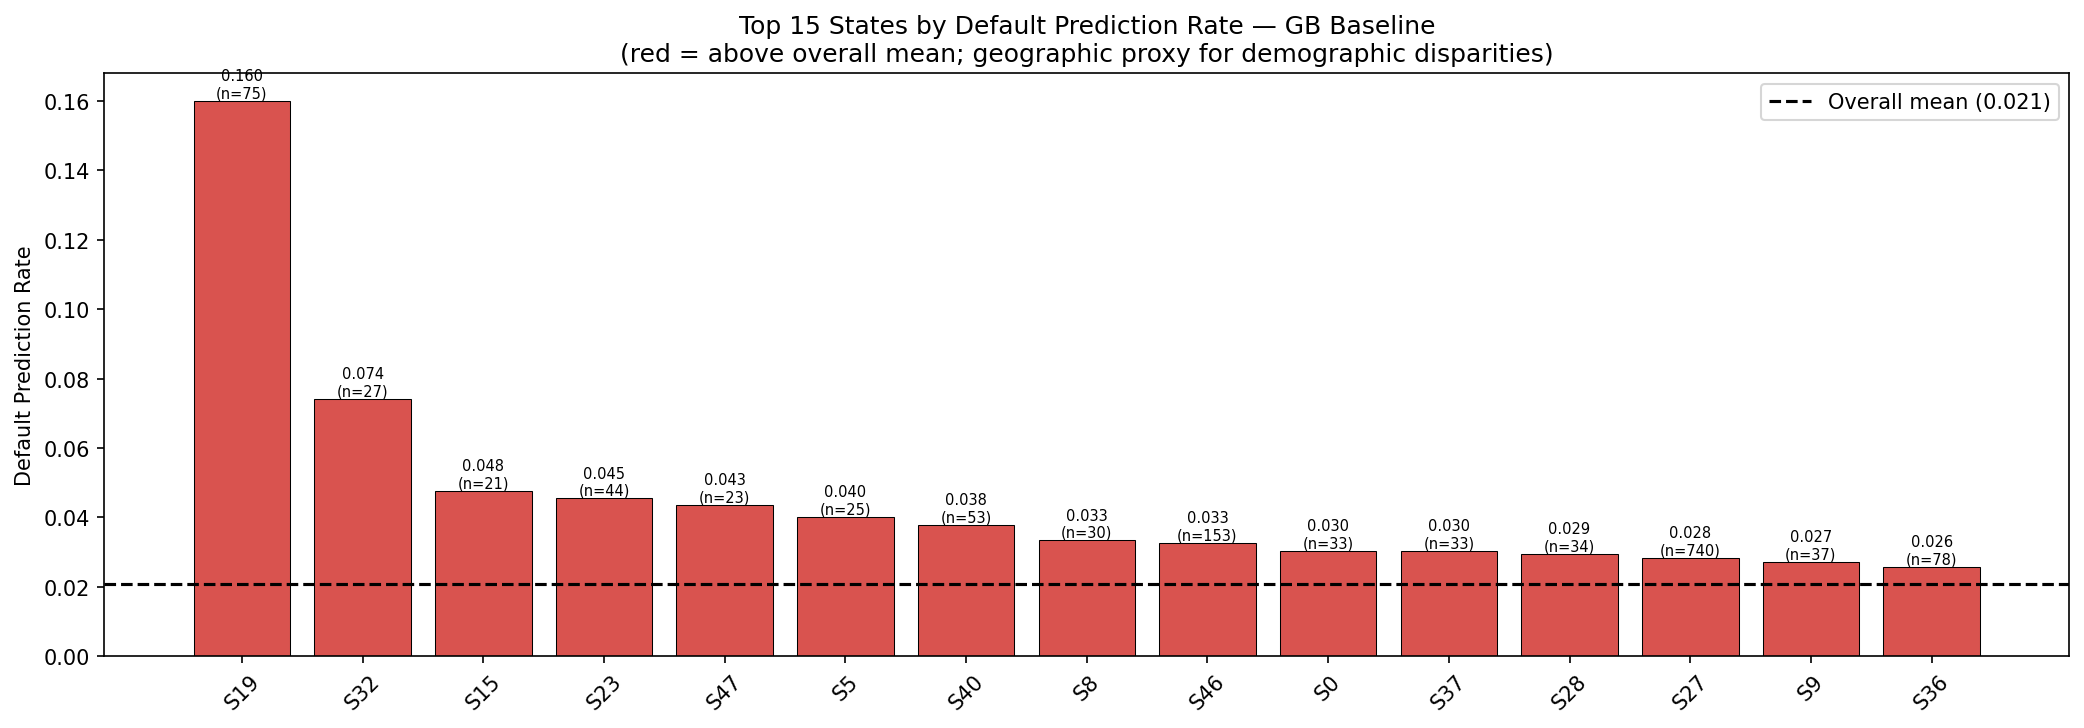

In [10]:
Image('../figures/stage2/agricultural_state_prediction_rates.png')

## 9. Key Findings

**Near-fair baseline:** SBA agricultural lending shows minimal business type disparity (DP=0.005-0.009), the smallest fairness gap in FAPE. Corporation, Individual, and Partnership entities receive near-equal default prediction rates at baseline.

**ThresholdOptimizer counterproductive:** When baseline fairness gap is near-zero, ThresholdOptimizer has no meaningful gap to close. Instead it introduces instability, worsening both DP and EO while reducing accuracy. GB DIR overcorrects from 0.653 to 1.095.

**GB AUC=0.938:** Highest baseline AUC in FAPE, agricultural lending features are highly predictive. The model is accurate but already near-fair on business type proxy.

**Cross-domain significance:** Agricultural lending is the only FAPE domain where ThresholdOptimizer intervention is counterproductive. Contrasts sharply with Law School (DP 0.329→0.006) and COMPAS (EOD +36.4% improvement). Not all domains require intervention.

**Dataset scope:** USDA NASS 2022 Census provides racial composition of US agricultural producers (see EDA notebook). LSMS-ISA Nigeria Wave 4 evaluated and excluded, outside US ECOA/EEOC regulatory scope.